Аналіз даних в таблиці

In [10]:
import pandas as pd
import numpy as np
df = pd.read_excel('/content/data_fin.xlsx')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30584 entries, 0 to 30583
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  30584 non-null  int64  
 1   Contract_dateStart       30584 non-null  object 
 2   Contractor_Gender        30584 non-null  int64  
 3   Age_Simple               30584 non-null  int64  
 4   bnpl_limit               30584 non-null  int64  
 5   orders_cnt_last_3m       30584 non-null  int64  
 6   total_spent_last_3m      30584 non-null  int64  
 7   avg_check_last_3m        30584 non-null  float64
 8   max_check_last_3m        30584 non-null  int64  
 9   expensive_orders_share   30584 non-null  float64
 10  avg_days_between_orders  30584 non-null  float64
 11  days_since_last_order    30584 non-null  int64  
 12  had_bnpl_before          30584 non-null  int64  
 13  bnpl_orders_cnt_last_3m  30584 non-null  int64  
 14  bnpl_share            

In [11]:
df.describe()

,user_id,Contractor_Gender,Age_Simple,bnpl_limit,orders_cnt_last_3m,total_spent_last_3m,avg_check_last_3m,max_check_last_3m,expensive_orders_share,avg_days_between_orders,days_since_last_order,had_bnpl_before,bnpl_orders_cnt_last_3m,bnpl_share,utilization,last_order_amount,last_order_was_bnpl,used_bnpl
count,3.058400e+04,30584.000000,30584.000000,30584.000000,30584.000000,30584.000000,30584.000000,30584.000000,30584.000000,30584.000000,30584.000000,30584.000000,30584.000000,30584.000000,30584.000000,30584.000000,30584.000000,30584.000000
mean,9.527437e+06,0.217990,39.969428,22788.955009,5.547018,5280.474660,664.987341,1404.602635,0.180130,551.319051,308.340963,0.547574,1.372253,0.149422,0.110642,1056.097044,0.269716,0.157435
std,3.512627e+06,0.412887,10.478873,9599.459769,11.745743,12422.635848,1649.912972,3086.479643,0.298157,492.673832,596.459470,0.497740,4.485915,0.306134,0.411681,2058.965059,0.443820,0.364217
min,3.600000e+01,0.000000,18.000000,1200.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.774798e+06,0.000000,33.000000,20000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.666666,16.000000,0.000000,0.000000,0.000000,0.000000,299.000000,0.000000,0.000000
50%,1.065734e+07,0.000000,39.000000,20000.000000,1.000000,828.000000,393.000000,550.000000,0.000000,999.000000,70.000000,1.000000,0.000000,0.000000,0.000000,626.000000,0.000000,0.000000
75%,1.235684e+07,0.000000,47.000000,30000.000000,6.000000,5542.250000,875.000000,1742.000000,0.272727,999.000000,232.000000,1.000000,1.000000,0.047619,0.014900,1170.000000,1.000000,0.000000
max,1.347662e+07,1.000000,72.000000,50000.000000,453.000000,556780.000000,81100.000000,81100.000000,1.000000,999.000000,2000.000000,1.000000,105.000000,1.000000,9.751000,81100.000000,1.000000,1.000000


Підготовка даних

In [12]:
#import pandas as pd
#import numpy as np

#df = pd.read_excel('/content/data_fin.xlsx')
data = df.copy()

data['no_orders_flag'] = (data['orders_cnt_last_3m'] == 0).astype(int)
data['no_recent_orders_flag'] = (data['days_since_last_order'] == 2000).astype(int)


# 999 і 2000 не трактуємо як реальні числа, а замінюємо на 0
# оскільки сам факт відсутності активності вже зафіксований прапорцями
data['avg_days_between_orders'] = data['avg_days_between_orders'].replace(999, 0)
data['days_since_last_order'] = data['days_since_last_order'].replace(2000, 0)

drop_cols = ['user_id', 'Contract_dateStart']
target_col = 'used_bnpl'

X = data.drop(columns=drop_cols + [target_col])
y = data[target_col]

print("Розмір X:", X.shape)
print("Частка класу 1:")
print(y.value_counts(normalize=True))
print("\nСписок ознак:")
print(X.columns.tolist())

Розмір X: (30584, 18)
Частка класу 1:
used_bnpl
0    0.842565
1    0.157435
Name: proportion, dtype: float64

Список ознак:
['Contractor_Gender', 'Age_Simple', 'bnpl_limit', 'orders_cnt_last_3m', 'total_spent_last_3m', 'avg_check_last_3m', 'max_check_last_3m', 'expensive_orders_share', 'avg_days_between_orders', 'days_since_last_order', 'had_bnpl_before', 'bnpl_orders_cnt_last_3m', 'bnpl_share', 'utilization', 'last_order_amount', 'last_order_was_bnpl', 'no_orders_flag', 'no_recent_orders_flag']


Поділ на train/test і стандартизація

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# поділ вибірки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# стандартизація для логістичної регресії та kNN
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (24467, 18)
Test shape: (6117, 18)


Логістична регресія

Logistic Regression
Accuracy: 0.885728298185385
ROC-AUC: 0.8483129779328359

Confusion matrix:
[[5056   98]
 [ 601  362]]

Classification report:
              precision    recall  f1-score   support

           0     0.8938    0.9810    0.9353      5154
           1     0.7870    0.3759    0.5088       963

    accuracy                         0.8857      6117
   macro avg     0.8404    0.6784    0.7221      6117
weighted avg     0.8769    0.8857    0.8682      6117



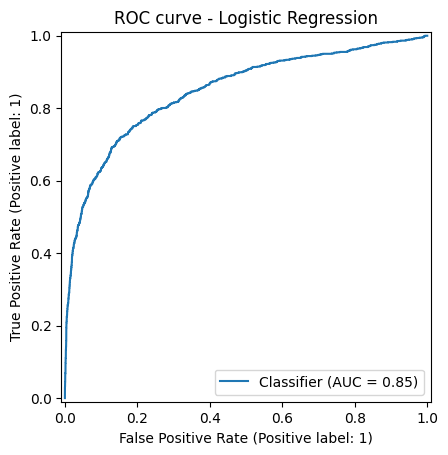

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, RocCurveDisplay
)
import matplotlib.pyplot as plt

# модель
log_model = LogisticRegression(max_iter=2000, random_state=42)
log_model.fit(X_train_scaled, y_train)

# прогнози
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

# метрики
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_log))
print("\nClassification report:")
print(classification_report(y_test, y_pred_log, digits=4))

# ROC-крива
RocCurveDisplay.from_predictions(y_test, y_prob_log)
plt.title("ROC curve - Logistic Regression")
plt.show()

In [16]:
log_coefs = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': log_model.coef_[0]
}).sort_values(by='coefficient', ascending=False)

log_coefs

,feature,coefficient
11,bnpl_orders_cnt_last_3m,1.219828
10,had_bnpl_before,0.351312
12,bnpl_share,0.177559
17,no_recent_orders_flag,0.130288
6,max_check_last_3m,0.128260
3,orders_cnt_last_3m,0.111168
8,avg_days_between_orders,0.103745
15,last_order_was_bnpl,0.083914
14,last_order_amount,0.028061
1,Age_Simple,0.020704


In [15]:
print("Top positive coefficients:")
print(log_coefs.head(10))

print("\nTop negative coefficients:")
print(log_coefs.sort_values(by='coefficient', ascending=True).head(10))

Top positive coefficients:
                    feature  coefficient
11  bnpl_orders_cnt_last_3m     1.219828
10          had_bnpl_before     0.351312
12               bnpl_share     0.177559
17    no_recent_orders_flag     0.130288
6         max_check_last_3m     0.128260
3        orders_cnt_last_3m     0.111168
8   avg_days_between_orders     0.103745
15      last_order_was_bnpl     0.083914
14        last_order_amount     0.028061
1                Age_Simple     0.020704

Top negative coefficients:
                   feature  coefficient
9    days_since_last_order    -0.512062
16          no_orders_flag    -0.229175
5        avg_check_last_3m    -0.216331
2               bnpl_limit    -0.185322
13             utilization    -0.168439
4      total_spent_last_3m    -0.108063
0        Contractor_Gender    -0.091023
7   expensive_orders_share    -0.021563
1               Age_Simple     0.020704
14       last_order_amount     0.028061


In [17]:
print(log_coefs.sort_values(by='coefficient', ascending=True).head(10))
print(feature_importance.head(15))

                   feature  coefficient
9    days_since_last_order    -0.512062
16          no_orders_flag    -0.229175
5        avg_check_last_3m    -0.216331
2               bnpl_limit    -0.185322
13             utilization    -0.168439
4      total_spent_last_3m    -0.108063
0        Contractor_Gender    -0.091023
7   expensive_orders_share    -0.021563
1               Age_Simple     0.020704
14       last_order_amount     0.028061
                    feature  importance
11  bnpl_orders_cnt_last_3m    0.791462
12               bnpl_share    0.087432
9     days_since_last_order    0.076477
8   avg_days_between_orders    0.021336
7    expensive_orders_share    0.008616
2                bnpl_limit    0.007353
3        orders_cnt_last_3m    0.001991
10          had_bnpl_before    0.001891
4       total_spent_last_3m    0.001460
5         avg_check_last_3m    0.001379
15      last_order_was_bnpl    0.000603
0         Contractor_Gender    0.000000
1                Age_Simple    0.000000


k-NN

k-NN
Accuracy: 0.8752656530979238
ROC-AUC: 0.7900344367519849

Confusion matrix:
[[4916  238]
 [ 525  438]]

Classification report:
              precision    recall  f1-score   support

           0     0.9035    0.9538    0.9280      5154
           1     0.6479    0.4548    0.5345       963

    accuracy                         0.8753      6117
   macro avg     0.7757    0.7043    0.7312      6117
weighted avg     0.8633    0.8753    0.8660      6117



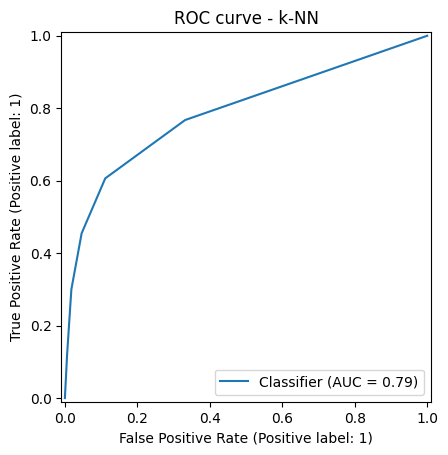

In [7]:
from sklearn.neighbors import KNeighborsClassifier

# для початку візьмемо k=5
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

print("k-NN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("\nClassification report:")
print(classification_report(y_test, y_pred_knn, digits=4))

RocCurveDisplay.from_predictions(y_test, y_prob_knn)
plt.title("ROC curve - k-NN")
plt.show()

Дерево рішень

Decision Tree
Accuracy: 0.889651790093183
ROC-AUC: 0.8576194839645058

Confusion matrix:
[[4942  212]
 [ 463  500]]

Classification report:
              precision    recall  f1-score   support

           0     0.9143    0.9589    0.9361      5154
           1     0.7022    0.5192    0.5970       963

    accuracy                         0.8897      6117
   macro avg     0.8083    0.7390    0.7665      6117
weighted avg     0.8809    0.8897    0.8827      6117



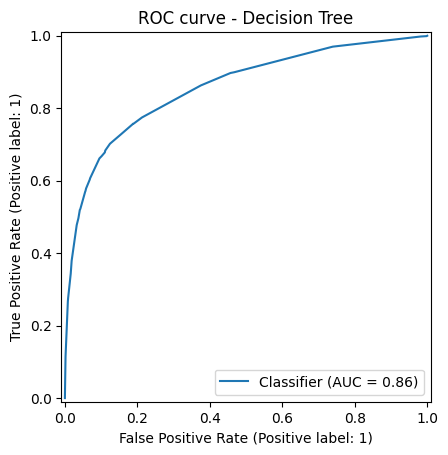

In [8]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_leaf=30,
    random_state=42
)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_tree))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_tree))
print("\nClassification report:")
print(classification_report(y_test, y_pred_tree, digits=4))

RocCurveDisplay.from_predictions(y_test, y_prob_tree)
plt.title("ROC curve - Decision Tree")
plt.show()

In [13]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': tree_model.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance.head(15)

,feature,importance
11,bnpl_orders_cnt_last_3m,0.791462
12,bnpl_share,0.087432
9,days_since_last_order,0.076477
8,avg_days_between_orders,0.021336
7,expensive_orders_share,0.008616
2,bnpl_limit,0.007353
3,orders_cnt_last_3m,0.001991
10,had_bnpl_before,0.001891
4,total_spent_last_3m,0.001460
5,avg_check_last_3m,0.001379


Порівняльна таблиця

In [9]:
results = pd.DataFrame({
    'model': ['Logistic Regression', 'k-NN', 'Decision Tree'],
    'accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_tree)
    ],
    'roc_auc': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_knn),
        roc_auc_score(y_test, y_prob_tree)
    ]
})

results

,model,accuracy,roc_auc
0,Logistic Regression,0.885728,0.848313
1,k-NN,0.875266,0.790034
2,Decision Tree,0.889652,0.857619


Це все було виведено для власного етсування і розуміння даних, тепер згрупую для фінальної таблиці в роботу

=== Основні результати моделей ===


,model,accuracy,roc_auc
0,Logistic Regression,0.8857,0.8483
1,k-NN,0.8753,0.7900
2,Decision Tree,0.8897,0.8576



=== Ключові метрики для класу 1 ===


,model,precision_class_1,recall_class_1,f1_class_1,specificity
0,Logistic Regression,0.7870,0.3759,0.5088,0.9810
1,k-NN,0.6479,0.4548,0.5345,0.9538
2,Decision Tree,0.7022,0.5192,0.5970,0.9589


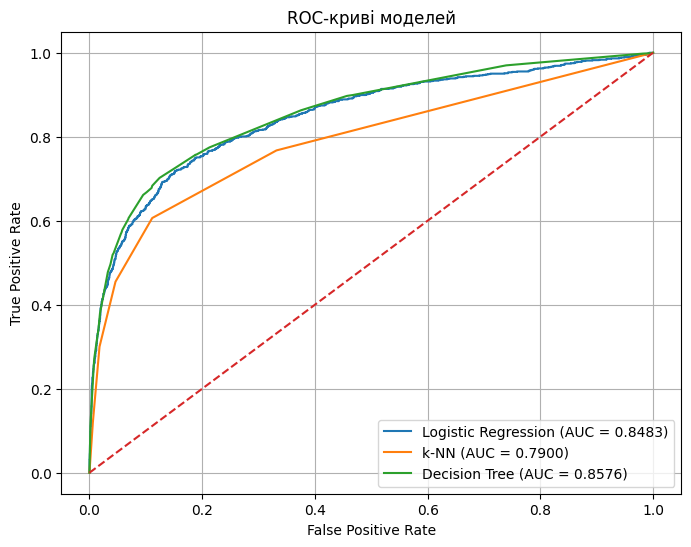

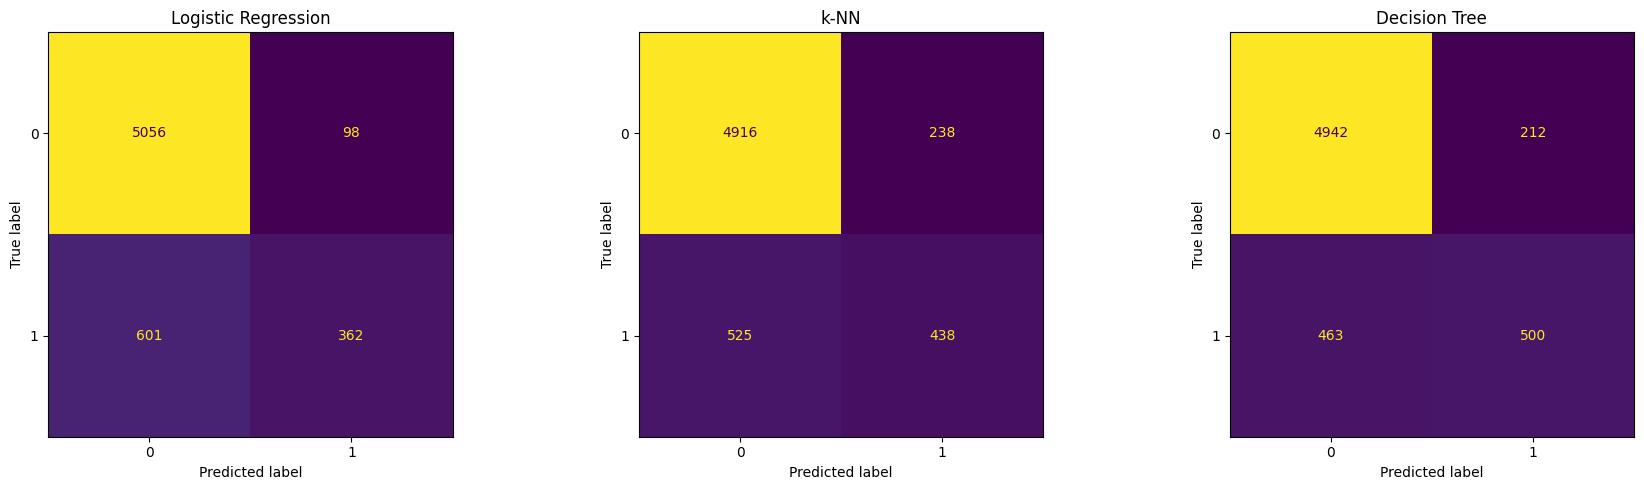

=== Топ додатних коефіцієнтів логістичної регресії ===


,feature,coefficient
11,bnpl_orders_cnt_last_3m,1.2198
10,had_bnpl_before,0.3513
12,bnpl_share,0.1776
17,no_recent_orders_flag,0.1303
6,max_check_last_3m,0.1283
3,orders_cnt_last_3m,0.1112
8,avg_days_between_orders,0.1037



=== Топ від’ємних коефіцієнтів логістичної регресії ===


,feature,coefficient
9,days_since_last_order,-0.5121
16,no_orders_flag,-0.2292
5,avg_check_last_3m,-0.2163
2,bnpl_limit,-0.1853
13,utilization,-0.1684
4,total_spent_last_3m,-0.1081
0,Contractor_Gender,-0.0910



=== Найважливіші ознаки дерева рішень ===


,feature,importance
11,bnpl_orders_cnt_last_3m,0.7915
12,bnpl_share,0.0874
9,days_since_last_order,0.0765
8,avg_days_between_orders,0.0213
7,expensive_orders_share,0.0086
2,bnpl_limit,0.0074
3,orders_cnt_last_3m,0.0020
10,had_bnpl_before,0.0019
4,total_spent_last_3m,0.0015
5,avg_check_last_3m,0.0014


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve
)

# 1. ПІДСУМКОВА ТАБЛИЦЯ МОДЕЛЕЙ
results = pd.DataFrame({
    'model': ['Logistic Regression', 'k-NN', 'Decision Tree'],
    'accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_tree)
    ],
    'roc_auc': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_knn),
        roc_auc_score(y_test, y_prob_tree)
    ]
}).round(4)

print("=== Основні результати моделей ===")
display(results)

# 2. КЛЮЧОВІ МЕТРИКИ ДЛЯ КЛАСУ 1
def get_main_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return pd.Series({
        'precision_class_1': precision,
        'recall_class_1': recall,
        'f1_class_1': f1,
        'specificity': specificity
    })

main_metrics = pd.DataFrame({
    'Logistic Regression': get_main_metrics(y_test, y_pred_log),
    'k-NN': get_main_metrics(y_test, y_pred_knn),
    'Decision Tree': get_main_metrics(y_test, y_pred_tree)
}).T.reset_index().rename(columns={'index': 'model'}).round(4)

print("\n=== Ключові метрики для класу 1 ===")
display(main_metrics)


# 3. ROC-КРИВІ ВСІХ МОДЕЛЕЙ
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_log):.4f})')
plt.plot(fpr_knn, tpr_knn, label=f'k-NN (AUC = {roc_auc_score(y_test, y_prob_knn):.4f})')
plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC = {roc_auc_score(y_test, y_prob_tree):.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-криві моделей')
plt.legend()
plt.grid(True)
plt.show()

# 4. МАТРИЦІ ПОМИЛОК
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=axes[0], colorbar=False)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, ax=axes[1], colorbar=False)
axes[1].set_title('k-NN')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree, ax=axes[2], colorbar=False)
axes[2].set_title('Decision Tree')

plt.tight_layout()
plt.show()


# 5. ТОП КОЕФІЦІЄНТІВ ЛОГІСТИЧНОЇ РЕГРЕСІЇ
log_coefs = pd.DataFrame({
    'feature': X.columns,
    'coefficient': log_model.coef_[0]
})

top_positive = log_coefs.sort_values(by='coefficient', ascending=False).head(7).round(4)
top_negative = log_coefs.sort_values(by='coefficient', ascending=True).head(7).round(4)

print("=== Топ додатних коефіцієнтів логістичної регресії ===")
display(top_positive)

print("\n=== Топ від’ємних коефіцієнтів логістичної регресії ===")
display(top_negative)


# 6. ТОП ВАЖЛИВИХ ОЗНАК ДЕРЕВА РІШЕНЬ
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': tree_model.feature_importances_
}).sort_values(by='importance', ascending=False).head(10).round(4)

print("\n=== Найважливіші ознаки дерева рішень ===")
display(feature_importance)